In [1]:
import pandas as pd

features = pd.read_csv(
    r"C:\Users\abhia\crazy ML\human+activity+recognition+using+smartphones\UCI HAR Dataset\UCI HAR Dataset\features.txt",
    sep = '\s+',
    header = None,
    names = ['index', 'feature']
)

feature_names = [
    f"{name}_{i}" for i, name in enumerate(features['feature'])
]
X_train = pd.read_csv(
    r"C:\Users\abhia\crazy ML\human+activity+recognition+using+smartphones\UCI HAR Dataset\UCI HAR Dataset\train\X_train.txt",
    sep = '\s+',
    header = None,
    names = feature_names
)

y_train = pd.read_csv(
    r"C:\Users\abhia\crazy ML\human+activity+recognition+using+smartphones\UCI HAR Dataset\UCI HAR Dataset\train\y_train.txt",
    header = None,
    names = ['Activity']
)

X_test = pd.read_csv(
    r"C:\Users\abhia\crazy ML\human+activity+recognition+using+smartphones\UCI HAR Dataset\UCI HAR Dataset\test\X_test.txt",
    sep = '\s+',
    header = None,
    names = feature_names
)

y_test = pd.read_csv(
    r"C:\Users\abhia\crazy ML\human+activity+recognition+using+smartphones\UCI HAR Dataset\UCI HAR Dataset\test\y_test.txt",
    header = None,
    names = ['Activity']
)

X = pd.concat([X_train, X_test], axis = 0)
y = pd.concat([y_train, y_test], axis = 0)

In [2]:
X_train.shape

(7352, 561)

In [3]:
X

,tBodyAcc-mean()-X_0,tBodyAcc-mean()-Y_1,tBodyAcc-mean()-Z_2,tBodyAcc-std()-X_3,tBodyAcc-std()-Y_4,tBodyAcc-std()-Z_5,tBodyAcc-mad()-X_6,tBodyAcc-mad()-Y_7,tBodyAcc-mad()-Z_8,tBodyAcc-max()-X_9,...,fBodyBodyGyroJerkMag-meanFreq()_551,fBodyBodyGyroJerkMag-skewness()_552,fBodyBodyGyroJerkMag-kurtosis()_553,"angle(tBodyAccMean,gravity)_554","angle(tBodyAccJerkMean),gravityMean)_555","angle(tBodyGyroMean,gravityMean)_556","angle(tBodyGyroJerkMean,gravityMean)_557","angle(X,gravityMean)_558","angle(Y,gravityMean)_559","angle(Z,gravityMean)_560"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2942,0.310155,-0.053391,-0.099109,-0.287866,-0.140589,-0.215088,-0.356083,-0.148775,-0.232057,0.185361,...,0.074472,-0.376278,-0.750809,-0.337422,0.346295,0.884904,-0.698885,-0.651732,0.274627,0.184784
2943,0.363385,-0.039214,-0.105915,-0.305388,0.028148,-0.196373,-0.373540,-0.030036,-0.270237,0.185361,...,0.101859,-0.320418,-0.700274,-0.736701,-0.372889,-0.657421,0.322549,-0.655181,0.273578,0.182412
2944,0.349966,0.030077,-0.115788,-0.329638,-0.042143,-0.250181,-0.388017,-0.133257,-0.347029,0.007471,...,-0.066249,-0.118854,-0.467179,-0.181560,0.088574,0.696663,0.363139,-0.655357,0.274479,0.181184
2945,0.237594,0.018467,-0.096499,-0.323114,-0.229775,-0.207574,-0.392380,-0.279610,-0.289477,0.007471,...,-0.046467,-0.205445,-0.617737,0.444558,-0.819188,0.929294,-0.008398,-0.659719,0.264782,0.187563


# DATA UNDERSTANDING

## feature strength

In [4]:
'''checking variance of data and vairance distribution'''

'checking variance of data and vairance distribution'

In [5]:
import numpy as np

features = X.columns.to_list()


In [6]:
variance = X.var()

variance_df = variance.to_frame(name = 'variance')

variance_df = variance_df.sort_values(by = 'variance')
print(variance_df.head())
print(variance_df.tail())

                                      variance
tBodyAcc-mean()-Y_1                   0.001379
tBodyAcc-mean()-Z_2                   0.002813
fBodyAccJerk-bandsEnergy()-57,64_388  0.002872
fBodyGyro-bandsEnergy()-33,40_478     0.003409
fBodyGyro-bandsEnergy()-33,48_484     0.004187
                                  variance
tGravityAcc-correlation()-X,Z_78  0.495532
fBodyAcc-entropy()-X_287          0.522666
tBodyAccJerkMag-entropy()_234     0.524056
fBodyAccJerk-entropy()-Y_367      0.539207
fBodyAccJerk-entropy()-X_366      0.561720


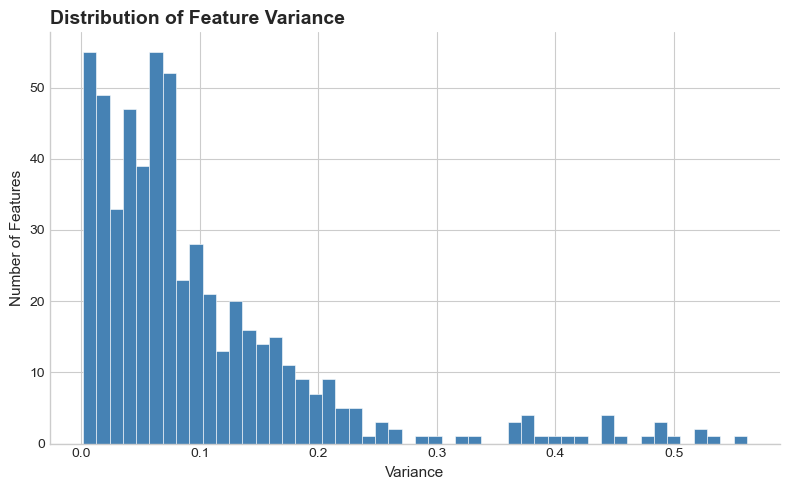

In [7]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(variance_df['variance'], bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xlabel("Variance", fontsize=11)
ax.set_ylabel("Number of Features", fontsize=11)
ax.set_title("Distribution of Feature Variance", fontsize=14, fontweight='bold', loc='left')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## feature redundancy

In [8]:
X.describe()

,tBodyAcc-mean()-X_0,tBodyAcc-mean()-Y_1,tBodyAcc-mean()-Z_2,tBodyAcc-std()-X_3,tBodyAcc-std()-Y_4,tBodyAcc-std()-Z_5,tBodyAcc-mad()-X_6,tBodyAcc-mad()-Y_7,tBodyAcc-mad()-Z_8,tBodyAcc-max()-X_9,...,fBodyBodyGyroJerkMag-meanFreq()_551,fBodyBodyGyroJerkMag-skewness()_552,fBodyBodyGyroJerkMag-kurtosis()_553,"angle(tBodyAccMean,gravity)_554","angle(tBodyAccJerkMean),gravityMean)_555","angle(tBodyGyroMean,gravityMean)_556","angle(tBodyGyroJerkMean,gravityMean)_557","angle(X,gravityMean)_558","angle(Y,gravityMean)_559","angle(Z,gravityMean)_560"
count,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,...,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000
mean,0.274347,-0.017743,-0.108925,-0.607784,-0.510191,-0.613064,-0.633593,-0.525697,-0.614989,-0.466732,...,0.126708,-0.298592,-0.617700,0.007705,0.002648,0.017683,-0.009219,-0.496522,0.063255,-0.054284
std,0.067628,0.037128,0.053033,0.438694,0.500240,0.403657,0.413333,0.484201,0.399034,0.538707,...,0.245443,0.320199,0.308796,0.336591,0.447364,0.616188,0.484770,0.511158,0.305468,0.268898
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.262625,-0.024902,-0.121019,-0.992360,-0.976990,-0.979137,-0.993293,-0.977017,-0.979064,-0.935788,...,-0.019481,-0.536174,-0.841847,-0.124694,-0.287031,-0.493108,-0.389041,-0.817288,0.002151,-0.131880
50%,0.277174,-0.017162,-0.108596,-0.943030,-0.835032,-0.850773,-0.948244,-0.843670,-0.845068,-0.874825,...,0.136245,-0.335160,-0.703402,0.008146,0.007668,0.017192,-0.007186,-0.715631,0.182028,-0.003882
75%,0.288354,-0.010625,-0.097589,-0.250293,-0.057336,-0.278737,-0.302033,-0.087405,-0.288149,-0.014641,...,0.288960,-0.113167,-0.487981,0.149005,0.291490,0.536137,0.365996,-0.521503,0.250790,0.102970
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


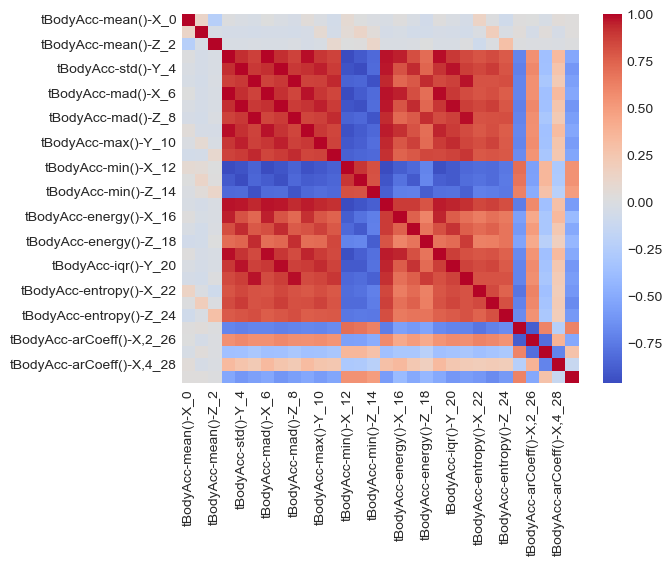

In [9]:
import seaborn as sns

sample_features = X.iloc[:, :30]   # first 30 features

sns.heatmap(sample_features.corr(), cmap='coolwarm')
plt.show()

In [10]:
'''Many features are not independent — they are different 
representations of the same motion signal'''

'Many features are not independent — they are different \nrepresentations of the same motion signal'

In [11]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10299 entries, 0 to 2946
Columns: 561 entries, tBodyAcc-mean()-X_0 to angle(Z,gravityMean)_560
dtypes: float64(561)
memory usage: 44.2 MB


In [12]:
X.isnull().sum().sum()

0

In [13]:
X.duplicated().sum()

0

## activity behavior

In [14]:
X['Activity'] = y.values

In [15]:
activity_map = {
    1: "WALKING",
    2: "WALKING_UPSTAIRS",
    3: "WALKING_DOWNSTAIRS",
    4: "SITTING",
    5: "STANDING",
    6: "LAYING"
}

X['Activity'] = X['Activity'].map(activity_map)

In [16]:
X['Activity']

0               STANDING
1               STANDING
2               STANDING
3               STANDING
4               STANDING
              ...       
2942    WALKING_UPSTAIRS
2943    WALKING_UPSTAIRS
2944    WALKING_UPSTAIRS
2945    WALKING_UPSTAIRS
2946    WALKING_UPSTAIRS
Name: Activity, Length: 10299, dtype: object

In [17]:
grouped = X.groupby('Activity').mean()

In [18]:
grouped

,tBodyAcc-mean()-X_0,tBodyAcc-mean()-Y_1,tBodyAcc-mean()-Z_2,tBodyAcc-std()-X_3,tBodyAcc-std()-Y_4,tBodyAcc-std()-Z_5,tBodyAcc-mad()-X_6,tBodyAcc-mad()-Y_7,tBodyAcc-mad()-Z_8,tBodyAcc-max()-X_9,...,fBodyBodyGyroJerkMag-meanFreq()_551,fBodyBodyGyroJerkMag-skewness()_552,fBodyBodyGyroJerkMag-kurtosis()_553,"angle(tBodyAccMean,gravity)_554","angle(tBodyAccJerkMean),gravityMean)_555","angle(tBodyGyroMean,gravityMean)_556","angle(tBodyGyroJerkMean,gravityMean)_557","angle(X,gravityMean)_558","angle(Y,gravityMean)_559","angle(Z,gravityMean)_560"
Activity,,,,,,,,,,,,,,,,,,,,,
LAYING,0.268649,-0.018318,-0.107436,-0.960932,-0.943507,-0.948069,-0.963395,-0.944099,-0.947261,-0.911610,...,0.165728,-0.342490,-0.658640,0.010366,0.016013,0.022788,0.009191,0.520261,-0.435944,-0.427749
SITTING,0.273060,-0.012690,-0.105517,-0.983446,-0.934881,-0.938982,-0.985280,-0.934798,-0.936671,-0.926703,...,0.177739,-0.384740,-0.686795,0.012034,0.002458,0.013413,-0.033260,-0.706042,0.006140,-0.089532
STANDING,0.279153,-0.016152,-0.106587,-0.984435,-0.932509,-0.939914,-0.987205,-0.933875,-0.937739,-0.921265,...,0.084865,-0.343769,-0.654989,0.006991,0.010397,0.004614,0.015957,-0.774143,0.209818,0.031743
WALKING,0.276337,-0.017907,-0.108882,-0.314644,-0.023583,-0.273921,-0.352470,-0.055491,-0.274098,-0.113458,...,0.130806,-0.071308,-0.400268,0.014918,-0.007011,0.011332,-0.019443,-0.761886,0.218599,0.059771
WALKING_DOWNSTAIRS,0.288137,-0.016312,-0.105762,0.100766,0.059549,-0.190805,0.032426,0.003907,-0.214569,0.417152,...,0.095759,-0.277020,-0.618394,-0.039692,-0.018665,0.203588,-0.076029,-0.780873,0.200189,0.055866
WALKING_UPSTAIRS,0.262295,-0.025923,-0.120538,-0.237990,-0.016033,-0.175450,-0.297094,-0.030865,-0.172811,-0.015003,...,0.094112,-0.361533,-0.682468,0.035371,0.006652,-0.129903,0.036432,-0.637980,0.278642,0.122794


In [19]:
sample = grouped.iloc[:,:10]

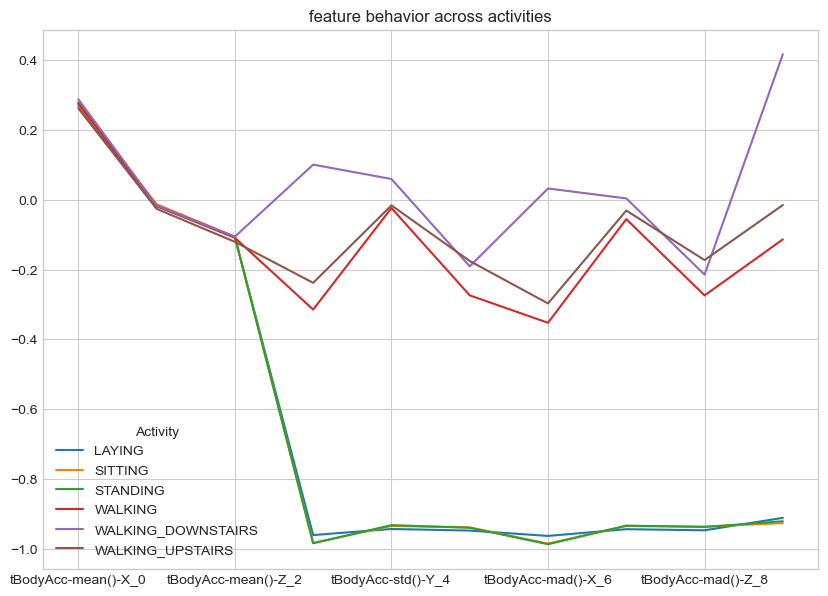

In [20]:
sample.T.plot(figsize = (10, 7))
plt.title('feature behavior across activities')
plt.show()

In [21]:
'''The activities do not separate uniformly across all features — 
some features clearly distinguish activities, 
while others show strong overlap.'''

'The activities do not separate uniformly across all features — \nsome features clearly distinguish activities, \nwhile others show strong overlap.'

In [22]:
'''The Human Activity Recognition dataset is a high-dimensional but highly 
structured dataset, where each data point represents a short window of human motion
captured through smartphone sensors and transformed into engineered features. 
Although the dataset contains 561 features, the effective information is much 
lower because many features are derived from the same underlying signals and 
therefore exhibit strong correlation and redundancy.

From the analysis, it is clear that feature importance is uneven. A large number of 
features show very low variance, indicating weak contribution to distinguishing 
activities, while a smaller subset carries strong signal and captures meaningful 
motion differences. In addition, correlation analysis reveals that features form 
groups with highly similar behavior, confirming that multiple features represent 
different mathematical views of the same physical phenomenon rather than independent 
information sources.

At the activity level, the dataset shows partial separability. Activities involving
significant motion, such as walking, tend to exhibit distinct patterns and are 
easier to differentiate. In contrast, low-movement activities like sitting and standing produce very similar sensor readings, leading to strong overlap in feature space. Some activities, such as laying, may appear similar or distinct depending on whether the selected features capture orientation-related information.

Overall, the dataset does not form perfectly clean clusters. Instead, it exhibits
a structured but overlapping feature space, where separability depends on the 
combination of features used. This explains why dimensionality reduction techniques
like PCA are necessary—to remove redundancy and capture the core underlying 
structure—and why clustering algorithms may struggle with certain activity 
distinctions.'''

'The Human Activity Recognition dataset is a high-dimensional but highly \nstructured dataset, where each data point represents a short window of human motion\ncaptured through smartphone sensors and transformed into engineered features. \nAlthough the dataset contains 561 features, the effective information is much \nlower because many features are derived from the same underlying signals and \ntherefore exhibit strong correlation and redundancy.\n\nFrom the analysis, it is clear that feature importance is uneven. A large number of \nfeatures show very low variance, indicating weak contribution to distinguishing \nactivities, while a smaller subset carries strong signal and captures meaningful \nmotion differences. In addition, correlation analysis reveals that features form \ngroups with highly similar behavior, confirming that multiple features represent \ndifferent mathematical views of the same physical phenomenon rather than independent \ninformation sources.\n\nAt the activity l